# Mini Project 9 - Part 2: Traditional ML Baseline
## TF-IDF + Logistic Regression

**Goal:** Build a traditional ML baseline to compare against the transformer.

**Approach:** TF-IDF vectorization + Logistic Regression with hyperparameter tuning

In [5]:
%pip install -q scikit-learn pandas numpy matplotlib seaborn tqdm

print("✅ Packages installed!")

Note: you may need to restart the kernel to use updated packages.
✅ Packages installed!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

SEED = 42
sns.set_style('whitegrid')

## 1. Load Processed Data

In [7]:
# Load splits from exploration notebook
train = pd.read_csv('data/train.csv')
val = pd.read_csv('data/val.csv')
test = pd.read_csv('data/test.csv')

print(f"Train: {len(train)} samples")
print(f"Val:   {len(val)} samples")
print(f"Test:  {len(test)} samples")

# Use aggressively cleaned text for TF-IDF
X_train = train['text_clean_aggressive'].values
y_train = train['class'].values

X_val = val['text_clean_aggressive'].values
y_val = val['class'].values

X_test = test['text_clean_aggressive'].values
y_test = test['class'].values

Train: 15849 samples
Val:   3963 samples
Test:  4954 samples


## 2. TF-IDF Vectorization

We'll experiment with:
- **max_features**: Vocabulary size
- **ngram_range**: Unigrams vs bigrams
- **min_df**: Minimum document frequency

In [8]:
# Create TF-IDF vectorizer
# We'll tune these parameters
vectorizer = TfidfVectorizer(
    max_features=5000,      # Top 5000 most frequent words
    ngram_range=(1, 2),     # Unigrams and bigrams
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.9,             # Ignore words in >90% of documents
    strip_accents='unicode',
    stop_words='english'    # Remove common English stop words
)

# Fit on training data and transform all splits
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"\nTop 20 features:")
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20])

TF-IDF matrix shape (train): (15849, 5000)
Vocabulary size: 5000

Top 20 features:
['10' '100' '1000' '11' '12' '13' '14' '14th' '15' '16' '17' '18' '1st'
 '20' '200' '2014' '2015' '21' '23' '24']


## 3. Baseline Model: Logistic Regression

Using `class_weight='balanced'` to handle class imbalance.

In [9]:
# Train baseline model
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',  # Handle imbalance
    random_state=SEED,
    n_jobs=-1
)

print("Training baseline model...")
baseline_model.fit(X_train_tfidf, y_train)
print("✅ Training complete!")

# Predictions
y_val_pred = baseline_model.predict(X_val_tfidf)
y_test_pred = baseline_model.predict(X_test_tfidf)

# Accuracy
val_acc = accuracy_score(y_val, y_val_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")

Training baseline model...
✅ Training complete!

Validation Accuracy: 0.8451
Test Accuracy:       0.8539


## 4. Hyperparameter Tuning

Tune `C` (regularization strength) using GridSearchCV.

In [10]:
# Parameter grid
param_grid = {
    'C': [0.1, 1.0, 10.0, 100.0],  # Regularization strength
}

# Grid search with F1-macro scoring (better for imbalanced data)
grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED, n_jobs=-1),
    param_grid,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Running grid search...")
grid_search.fit(X_train_tfidf, y_train)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1 (macro): {grid_search.best_score_:.4f}")

# Use best model
best_model = grid_search.best_estimator_

Running grid search...
Fitting 3 folds for each of 4 candidates, totalling 12 fits

✅ Best parameters: {'C': 1.0}
Best cross-validation F1 (macro): 0.7158


## 5. Evaluation on Test Set

In [11]:
# Predictions with best model
y_test_pred_best = best_model.predict(X_test_tfidf)
y_test_proba = best_model.predict_proba(X_test_tfidf)

# Metrics
test_acc_best = accuracy_score(y_test, y_test_pred_best)
test_f1_macro = f1_score(y_test, y_test_pred_best, average='macro')
test_f1_weighted = f1_score(y_test, y_test_pred_best, average='weighted')

print("="*70)
print("TF-IDF BASELINE - FINAL TEST RESULTS")
print("="*70)
print(f"Accuracy:        {test_acc_best:.4f}")
print(f"F1 (macro):      {test_f1_macro:.4f}")
print(f"F1 (weighted):   {test_f1_weighted:.4f}")
print("="*70)

TF-IDF BASELINE - FINAL TEST RESULTS
Accuracy:        0.8539
F1 (macro):      0.7197
F1 (weighted):   0.8690


## 6. Per-Class Performance

In [12]:
# Classification report
class_names = ['Hate speech', 'Offensive', 'Neither']
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_best, target_names=class_names, digits=4))


Classification Report:
              precision    recall  f1-score   support

 Hate speech     0.3078    0.6070    0.4085       285
   Offensive     0.9693    0.8561    0.9092      3837
     Neither     0.7697    0.9279    0.8414       832

    accuracy                         0.8539      4954
   macro avg     0.6823    0.7970    0.7197      4954
weighted avg     0.8977    0.8539    0.8690      4954



## 7. Confusion Matrix

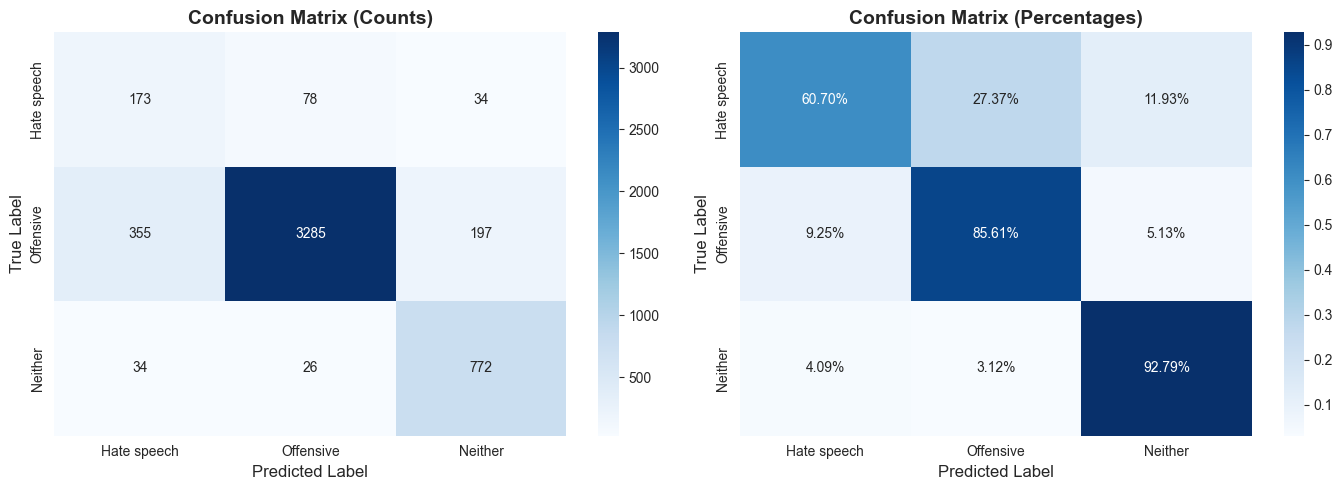

In [13]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred_best)

# Normalize for percentages
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_ylabel('True Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

# Percentages
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_ylabel('True Label', fontsize=12)
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Error Analysis: Hardest Examples

In [14]:
# Find misclassified examples
test_df = test.copy()
test_df['predicted'] = y_test_pred_best
test_df['confidence'] = y_test_proba.max(axis=1)
test_df['correct'] = (test_df['class'] == test_df['predicted'])

# Misclassified examples
errors = test_df[~test_df['correct']]

print(f"Total errors: {len(errors)} / {len(test_df)} ({len(errors)/len(test_df)*100:.2f}%)")
print("\nError breakdown by true class:")
for cls in [0, 1, 2]:
    label = {0: 'Hate speech', 1: 'Offensive', 2: 'Neither'}[cls]
    cls_errors = len(errors[errors['class'] == cls])
    cls_total = len(test_df[test_df['class'] == cls])
    print(f"  {label:15s}: {cls_errors:3d} / {cls_total:4d} ({cls_errors/cls_total*100:5.2f}% error rate)")

Total errors: 724 / 4954 (14.61%)

Error breakdown by true class:
  Hate speech    : 112 /  285 (39.30% error rate)
  Offensive      : 552 / 3837 (14.39% error rate)
  Neither        :  60 /  832 ( 7.21% error rate)


In [15]:
# Show 10 hardest misclassified examples (lowest confidence)
hardest_errors = errors.nsmallest(10, 'confidence')

print("\n" + "="*80)
print("10 HARDEST MISCLASSIFICATIONS (Lowest Confidence)")
print("="*80)

for idx, (i, row) in enumerate(hardest_errors.iterrows(), 1):
    true_label = {0: 'Hate', 1: 'Offensive', 2: 'Neither'}[row['class']]
    pred_label = {0: 'Hate', 1: 'Offensive', 2: 'Neither'}[row['predicted']]
    
    print(f"\nExample {idx}:")
    print(f"  Text: {row['text_clean']}")
    print(f"  True: {true_label} | Predicted: {pred_label} | Confidence: {row['confidence']:.3f}")


10 HARDEST MISCLASSIFICATIONS (Lowest Confidence)

Example 1:
  Text: @YunGMiGo @BigMoneyNiquee lol send dat nicca clean out talmbout some n what if he really is &#128514;&#128514;&#128514;
  True: Offensive | Predicted: Neither | Confidence: 0.350

Example 2:
  Text: @IMNOTMAKINGITUP Hey u just followed me not long ago. Gonna nip that in da bud. like ur bio tho. U know the white devils stole our our
  True: Neither | Predicted: Offensive | Confidence: 0.355

Example 3:
  Text: @LaBugg09 &#128514;&#128514; my fault it sound like it fucc nicca
  True: Neither | Predicted: Offensive | Confidence: 0.365

Example 4:
  Text: Got damn the Lakers trash....
  True: Neither | Predicted: Hate | Confidence: 0.367

Example 5:
  Text: I would def call Dwight a cradle robbing faggot if I were Kobe.
  True: Offensive | Predicted: Hate | Confidence: 0.369

Example 6:
  Text: RT @KayciMalynn: &#8220;@__0utcast___: Kayci and I greet each other by saying "hey cunt" like it makes me lol&#8221; -The only 

## 9. Save Baseline Results

In [16]:
# Save results for comparison with transformer
baseline_results = {
    'model': 'TF-IDF + Logistic Regression',
    'test_accuracy': test_acc_best,
    'test_f1_macro': test_f1_macro,
    'test_f1_weighted': test_f1_weighted,
    'best_params': grid_search.best_params_,
    'confusion_matrix': cm.tolist()
}

import json
with open('data/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)

print("✅ Baseline results saved to ../data/baseline_results.json")

✅ Baseline results saved to ../data/baseline_results.json


---

## Summary: TF-IDF Baseline

**Final Results:**
- Test Accuracy: [0.8539]
- F1 (macro): [0.7179]
- F1 (weighted): [0.8690]

**Observations:**
1. **Best performing class**: [Offensive language got the highest F1 score (0.9092), which makes sense since it has the most training data (77% of the dataset).]
2. **Worst performing class**: [Hate speech had the lowest F1 score (0.4085) and the highest error rate (39.30%). The model only got 60.70% of hate speech examples correct, and often confused them with offensive language. This is likely because hate speech is rare in training data and shares similar vocabulary with offensive language.]
3. **Common errors**: [The biggest confusion is between hate speech and offensive language. Looking at the hardest misclassifications, many examples use slurs or strong language that could belong to either class. Without context, TF-IDF cannot tell the difference between a slur used to target someone versus one used casually.]
